In [2]:
%pip install matplotlib seaborn pandas scikit-learn simpletransformers torch

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------- ----------------------- 3.4/8.2 MB 16.4 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.2 MB 15.6 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 14.4 MB/s  0:00:00
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   - -------------------------------------- 3.4/123.0 MB 16.4 MB/s eta 0:00:08
   -- ------------------------------------- 7.1/123.0 MB 16.4 MB/s eta 0:00:08
   --- -------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [2]:
%pip install contractions textstat wordcloud

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import contractions
import textstat

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset
import torch

sns.set_style("whitegrid")

c:\Users\AMRUTHA\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
column_names = [
    'id',
    'label',
    'statement',
    'subjects',
    'speaker',
    'speaker_job',
    'state_info',
    'party_affiliation',
    'barely_true_counts',
    'false_counts',
    'half_true_counts',
    'mostly_true_counts',
    'pants_on_fire_counts',
    'context'
]

train_df = pd.read_table('Dataset/train.tsv')
test_df = pd.read_table('Dataset/test.tsv')
valid_df = pd.read_table('Dataset/valid.tsv')

train_df.columns = column_names
valid_df.columns = column_names
test_df.columns = column_names

print(train_df.shape)
print(valid_df.shape)
print(test_df.shape)

(10239, 14)
(1283, 14)
(1266, 14)


In [7]:
train_df.head()

,id,label,statement,subjects,speaker,speaker_job,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
1,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
2,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
3,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN
4,12465.json,true,The Chicago Bears have had more starting quart...,education,robin-vos,Wisconsin Assembly speaker,Wisconsin,republican,0.0,3.0,2.0,5.0,1.0,a an online opinion-piece


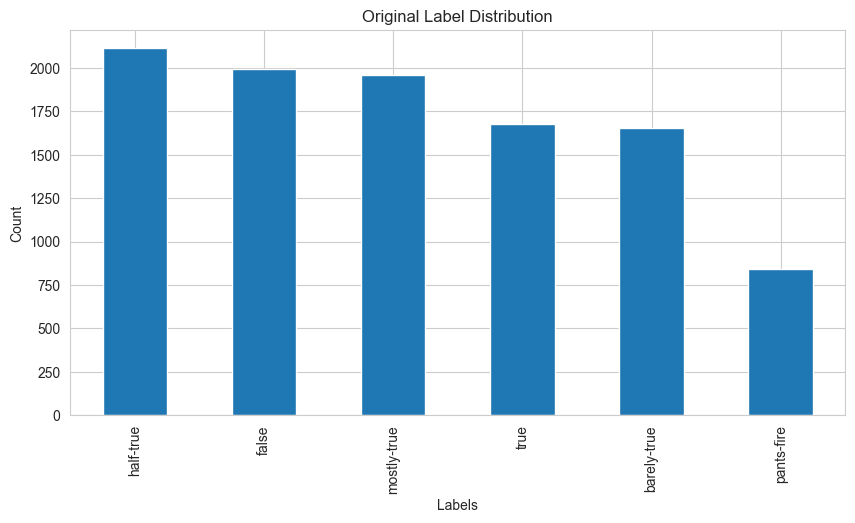

In [8]:
plt.figure(figsize=(10,5))
train_df['label'].value_counts().plot(kind='bar')
plt.title('Original Label Distribution')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.show()

Convert Multi-Class to Binary Labels

In [9]:
fake_labels = ['pants-fire', 'false', 'barely-true']
real_labels = ['half-true', 'mostly-true', 'true']


def convert_label(label):
    if label in fake_labels:
        return 0
    else:
        return 1


train_df['target'] = train_df['label'].apply(convert_label)
valid_df['target'] = valid_df['label'].apply(convert_label)
test_df['target'] = test_df['label'].apply(convert_label)

train_df[['label', 'target']].head()

,label,target
0,half-true,1
1,mostly-true,1
2,false,0
3,half-true,1
4,true,1


Text Cleaning Function

In [12]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))


def clean_text(text):
    text = str(text).lower()

    text = contractions.fix(text)

    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'www\S+', '', text)

    text = re.sub(r'\d+', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return ' '.join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AMRUTHA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Apply Cleaning

In [13]:
train_df['clean_text'] = train_df['statement'].apply(clean_text)
valid_df['clean_text'] = valid_df['statement'].apply(clean_text)
test_df['clean_text'] = test_df['statement'].apply(clean_text)

train_df[['statement', 'clean_text']].head()

,statement,clean_text
0,When did the decline of coal start? It started...,decline coal start started natural gas took st...
1,"Hillary Clinton agrees with John McCain ""by vo...",hillary clinton agrees john mccain voting give...
2,Health care reform legislation is likely to ma...,health care reform legislation likely mandate ...
3,The economic turnaround started at the end of ...,economic turnaround started end term
4,The Chicago Bears have had more starting quart...,chicago bears starting quarterbacks last years...


Linguistic Feature Engineering

In [14]:

def extract_features(text):

    text = str(text)

    num_chars = len(text)
    num_words = len(text.split())
    num_sentences = len(re.split(r'[.!?]+', text))

    avg_word_length = np.mean([len(word) for word in text.split()]) if num_words > 0 else 0

    exclamation_count = text.count('!')
    question_count = text.count('?')
    capital_ratio = sum(1 for c in text if c.isupper()) / (len(text)+1)

    readability = textstat.flesch_reading_ease(text)

    return pd.Series([
        num_chars,
        num_words,
        num_sentences,
        avg_word_length,
        exclamation_count,
        question_count,
        capital_ratio,
        readability
    ])

Create Feature Columns

In [15]:
feature_names = [
    'num_chars',
    'num_words',
    'num_sentences',
    'avg_word_length',
    'exclamation_count',
    'question_count',
    'capital_ratio',
    'readability'
]

train_df[feature_names] = train_df['statement'].apply(extract_features)
valid_df[feature_names] = valid_df['statement'].apply(extract_features)
test_df[feature_names] = test_df['statement'].apply(extract_features)

train_df.head()

,id,label,statement,subjects,speaker,speaker_job,state_info,party_affiliation,barely_true_counts,false_counts,...,target,clean_text,num_chars,num_words,num_sentences,avg_word_length,exclamation_count,question_count,capital_ratio,readability
0,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,...,1,decline coal start started natural gas took st...,141.0,24.0,4.0,4.916667,0.0,1.0,0.042254,60.705000
1,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,...,1,hillary clinton agrees john mccain voting give...,105.0,19.0,2.0,4.578947,0.0,0.0,0.075472,62.876316
2,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,...,0,health care reform legislation likely mandate ...,78.0,12.0,2.0,5.583333,0.0,0.0,0.012658,53.655000
3,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,...,1,economic turnaround started end term,54.0,10.0,2.0,4.500000,0.0,0.0,0.018182,61.325000
4,12465.json,true,The Chicago Bears have had more starting quart...,education,robin-vos,Wisconsin Assembly speaker,Wisconsin,republican,0.0,3.0,...,1,chicago bears starting quarterbacks last years...,155.0,27.0,2.0,4.777778,0.0,0.0,0.032051,54.096667


Compare Linguistic Features

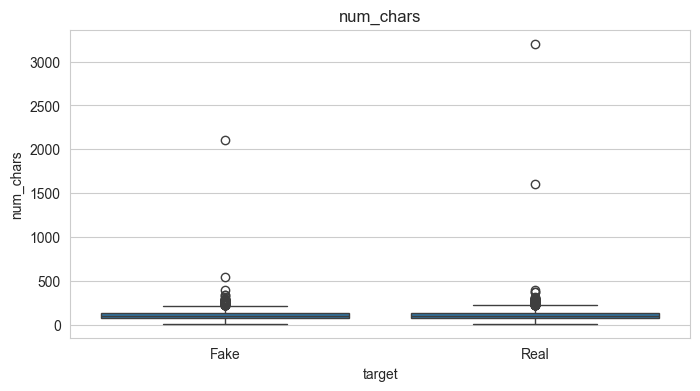

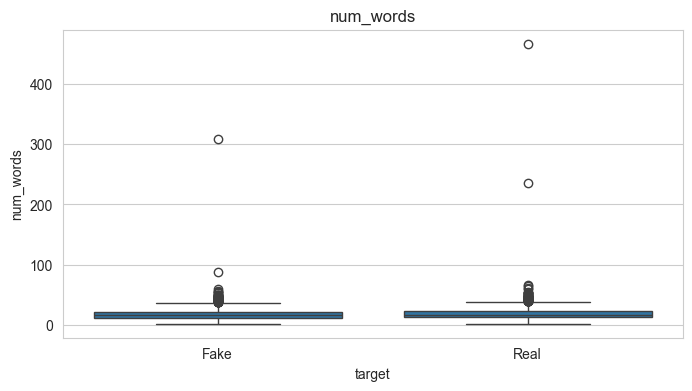

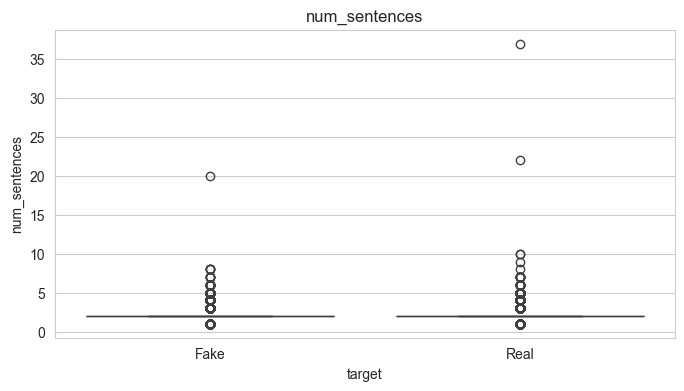

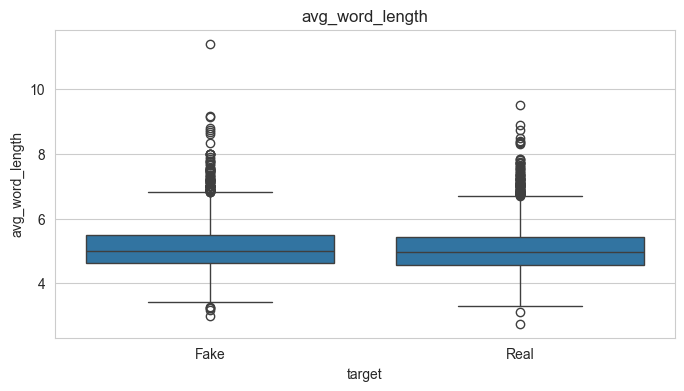

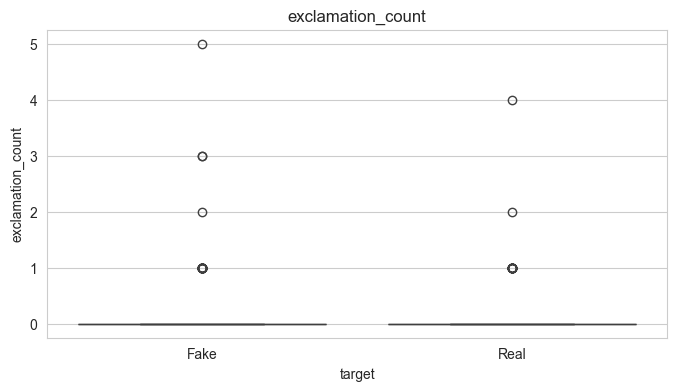

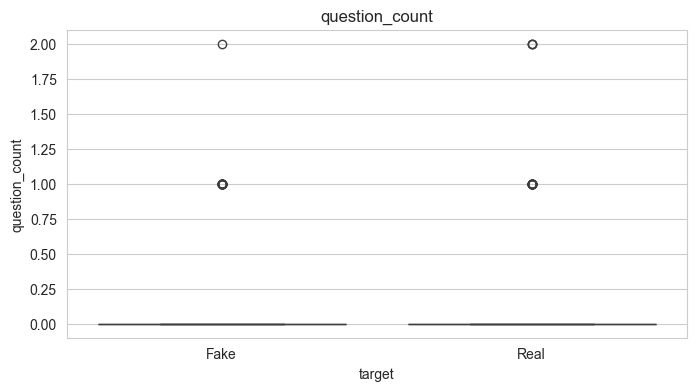

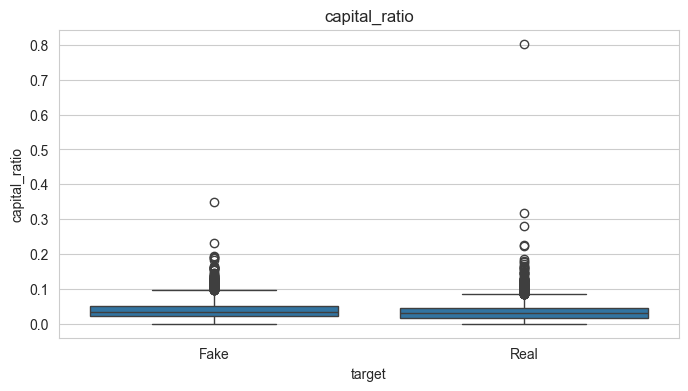

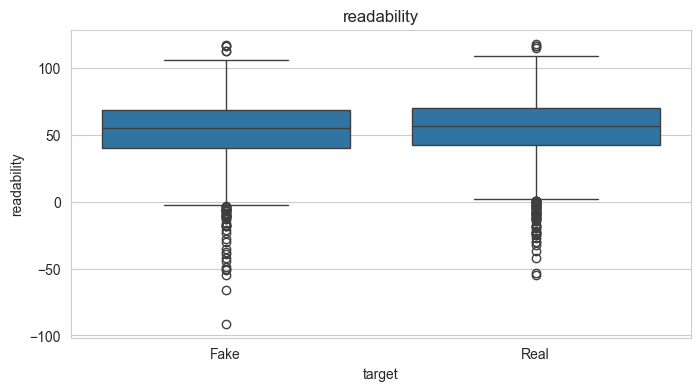

In [16]:
for feature in feature_names:

    plt.figure(figsize=(8,4))

    sns.boxplot(x='target', y=feature, data=train_df)

    plt.xticks([0,1], ['Fake', 'Real'])
    plt.title(feature)

    plt.show()

Word Cloud for Fake News

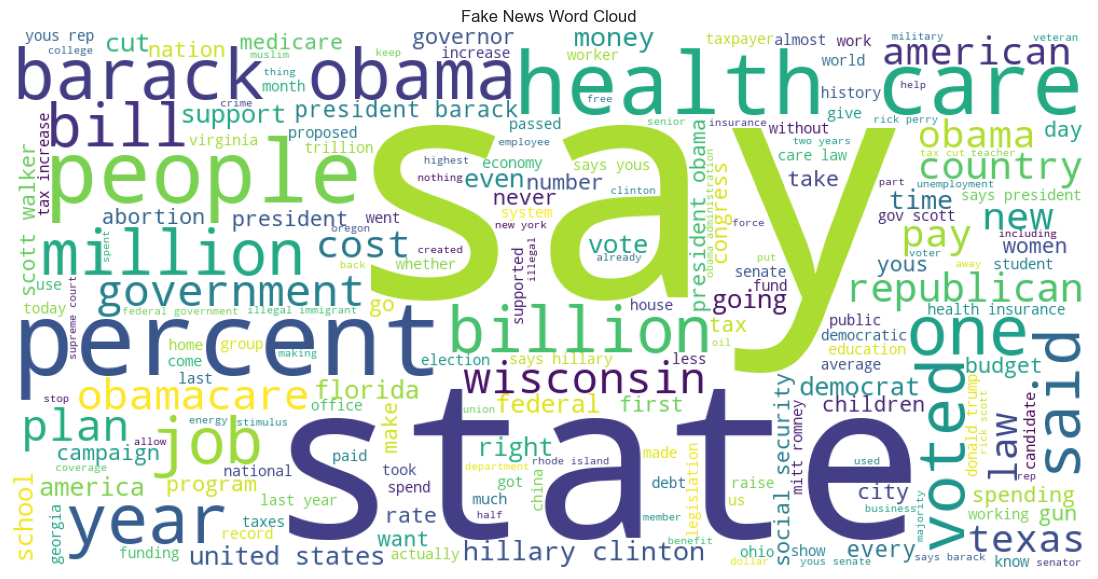

In [17]:
fake_text = ' '.join(train_df[train_df['target']==0]['clean_text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(fake_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Fake News Word Cloud')
plt.show()

Word Cloud for Real News

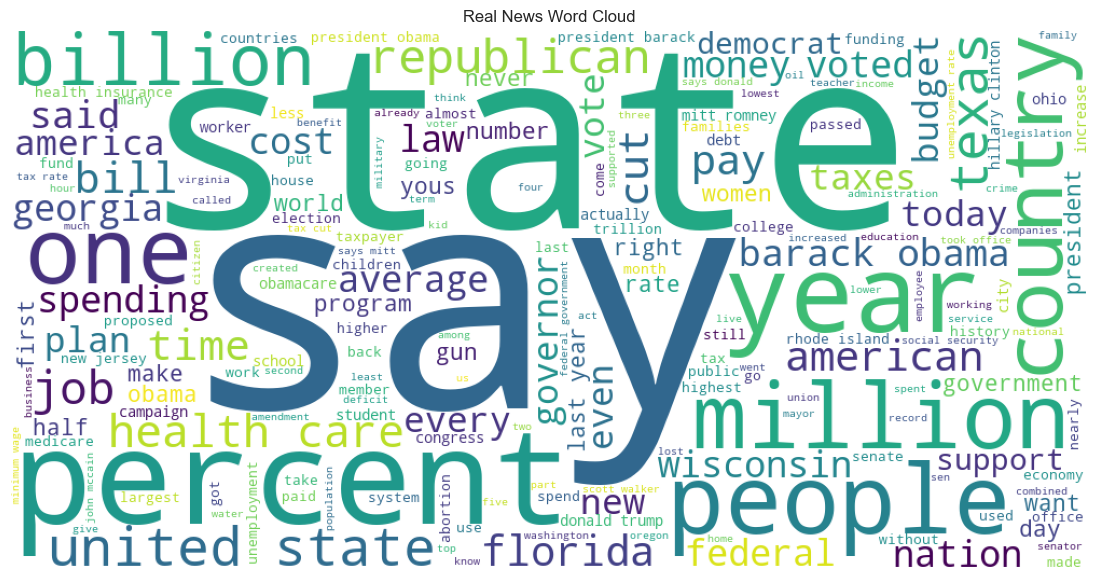

In [18]:
real_text = ' '.join(train_df[train_df['target']==1]['clean_text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(real_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Real News Word Cloud')
plt.show()

TF-IDF Vectorization

In [19]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(train_df['clean_text'])
X_valid_tfidf = vectorizer.transform(valid_df['clean_text'])
X_test_tfidf = vectorizer.transform(test_df['clean_text'])

y_train = train_df['target']
y_valid = valid_df['target']
y_test = test_df['target']

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Logistic Regression
# We use the X_train_tfidf and y_train variables your teammate defined
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)

print("--- Logistic Regression Results ---")
print(classification_report(y_test, lr_preds))

# 2. Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1)
gb_model.fit(X_train_tfidf, y_train)
gb_preds = gb_model.predict(X_test_tfidf)

print("--- Gradient Boosting Results ---")
print(classification_report(y_test, gb_preds))

--- Logistic Regression Results ---
              precision    recall  f1-score   support

           0       0.54      0.57      0.55       553
           1       0.65      0.63      0.64       713

    accuracy                           0.60      1266
   macro avg       0.60      0.60      0.60      1266
weighted avg       0.61      0.60      0.60      1266

--- Gradient Boosting Results ---
              precision    recall  f1-score   support

           0       0.58      0.21      0.31       553
           1       0.59      0.88      0.71       713

    accuracy                           0.59      1266
   macro avg       0.58      0.55      0.51      1266
weighted avg       0.58      0.59      0.53      1266

